# Handwritten Signature Verification on UTSig (OCSVM: RAW vs HOG)

**Bonus / stretch cross-dataset experiment.** This notebook is a *separate* pipeline from the
CEDAR notebook (`cedar_hog_ocsvm_signverif_experiment3.ipynb`), which remains the primary,
locked thesis result. Nothing here changes or re-runs anything CEDAR-related.

**Why this exists:** the CEDAR experiments established that going from 12 to 18 genuine
training signatures per writer (out of CEDAR's max of 24) roughly doubled F1. That result
raised the natural follow-up question -- does an even larger per-writer genuine reference set
help further? CEDAR itself is now exhausted (24/24 genuine signatures already used across the
two CEDAR experiments), so answering that question requires a different dataset. UTSig was
selected after a real dataset survey (GPDS -- officially withdrawn for GDPR reasons; its
synthetic replacements and an unofficial Kaggle mirror both cap at 24 genuine/writer, same as
CEDAR; MCYT-75 -- only 15 genuine/writer; ICDAR SigComp -- smaller, disclaimer-gated;
BHSig260 -- also 24 genuine/writer, same as CEDAR) because it is the only dataset found with
*more* genuine references per writer than CEDAR: **27**, confirmed uniform across all 115
writers by an actual exploration-notebook run against the real downloaded data (not just the
dataset page's description).

**Dataset structure (confirmed, not assumed):**
- `Genuine/<writer_id>/<n>.tif` -- 115 writers x 27 genuine signatures each (uniform, 0 outliers)
- `Forgery/Skilled/<writer_id>/<n>.tif` -- 115 writers x 6 skilled forgeries each (uniform, 0 outliers)
- `Forgery/Simple/<writer_id>/<n>.tif` -- 36/writer -- **not used in this notebook**, earmarked as optional future-work robustness check
- `Forgery/Opposite Hand/<writer_id>/<n>.tif` -- 3/writer -- **not used in this notebook**, same reason
- Images are grayscale (`mode='L'`) TIFFs of variable size (e.g. 932x998, 1007x707) -- PIL reads these natively, no format conversion needed anywhere in this pipeline.

**Why Skilled, and not Simple or Opposite Hand:** Skilled forgeries (the forger practices an
imitation of the actual signature) are the closest analog to CEDAR's forged class and the
standard hardest-case benchmark in this literature, so it is the fair, comparable choice for
a RAW-vs-HOG / CEDAR-vs-UTSig comparison. A visual spot-check of one writer's Genuine /
Opposite Hand / Simple / Skilled samples (done before building this notebook) confirmed the
Skilled sample tracks the genuine signature's shape far more closely than the other two
forgery types -- consistent with what "Skilled" is supposed to mean, and a reasonable sanity
check that the folder labels are what they claim to be.

**Split (uses every available signature -- no leftover, unlike CEDAR's 18/24):**
- Genuine: 21 train / 3 validation / 3 final-test (21+3+3 = all 27)
- Skilled-forged: 3 validation / 3 final-test (3+3 = all 6; none held out for training, since OCSVM is one-class and only ever trains on genuine signatures)

**Important asymmetry vs. CEDAR, stated up front:** CEDAR's final-test composition is 3
genuine + 12 forged per writer (165 genuine / 660 forged overall -- a deliberately skewed
80% forged evaluation set, because CEDAR has 24 forged signatures/writer to draw from). UTSig
only has 6 skilled forgeries per writer total, so the final-test composition here is 3
genuine + 3 forged per writer (345 / 345 overall -- a 50/50 evaluation set). This means the
trivial Reject-All / Accept-All baselines, and therefore what counts as "beating the
baseline," are numerically different between the two datasets and are **not directly
comparable without accounting for this** -- see the baselines section near the end.

**Methodology is otherwise identical to CEDAR's final, locked pipeline:** same
`preprocess_signature` (Otsu ink-mask -> density-threshold crop -> aspect-cap with the
`ceil()` fix -> resize+pad to 100x100), same RAW and HOG feature extractors, one global
`StandardScaler` per representation fit only on pooled training-genuine data, the same
data-driven reference-gamma method (`1/(n_features * X.var())`) with the same fixed
multiplier grid and the same nu grid, tuned exactly once on validation and locked before
final-test is touched. The within-writer gamma re-anchoring idea was tested on CEDAR and
did NOT improve validation F1 there, so it is not repeated here -- only the single,
pre-specified pooled-reference tuning is run.

## Imports

In [1]:
import numpy as np
import pandas as pd

from PIL import Image, ImageOps
from math import floor, ceil
from skimage.feature import hog
from skimage.filters import threshold_otsu

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

import os
from pathlib import Path
from collections import Counter

import hashlib
import random

from scipy.spatial.distance import pdist

print("Imports loaded.")


Imports loaded.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Dataset Setup

**Edit `UTSIG_DIR` below if your folder is somewhere else in Drive.** This assumes the same
layout the exploration notebook confirmed against the real data: a folder that directly
contains `Genuine/` and `Forgery/`.

In [3]:
UTSIG_DIR = Path("/content/drive/MyDrive/utsig-dataset-thesis/UTSig")
GENUINE_DIR = UTSIG_DIR / "Genuine"
SKILLED_FORGED_DIR = UTSIG_DIR / "Forgery" / "Skilled"

print("UTSig root:", UTSIG_DIR)
print("Genuine directory:", GENUINE_DIR)
print("Skilled-forged directory:", SKILLED_FORGED_DIR)

assert UTSIG_DIR.exists(), "UTSIG_DIR not found -- check the path."
assert GENUINE_DIR.exists(), "Genuine/ not found under UTSIG_DIR."
assert SKILLED_FORGED_DIR.exists(), "Forgery/Skilled/ not found under UTSIG_DIR."

# Files live one level down, inside a per-writer folder: Genuine/<writer_id>/<n>.tif
genuine_files = sorted(GENUINE_DIR.glob("*/*.tif"))
forged_files = sorted(SKILLED_FORGED_DIR.glob("*/*.tif"))

print("\nNumber of genuine TIFF files:", len(genuine_files))
print("Number of skilled-forged TIFF files:", len(forged_files))

assert len(genuine_files) == 115 * 27, "Unexpected number of genuine files!"
assert len(forged_files) == 115 * 6, "Unexpected number of skilled-forged files!"

print("\nDataset verification PASSED.")


UTSig root: /content/drive/MyDrive/utsig-dataset-thesis/UTSig
Genuine directory: /content/drive/MyDrive/utsig-dataset-thesis/UTSig/Genuine
Skilled-forged directory: /content/drive/MyDrive/utsig-dataset-thesis/UTSig/Forgery/Skilled

Number of genuine TIFF files: 3105
Number of skilled-forged TIFF files: 690

Dataset verification PASSED.


## Extract Writer IDs

Unlike CEDAR (writer ID encoded in the filename, e.g. `original_17_21.png`), UTSig genuine
and forgery filenames are purely numeric (`1.tif`, `10.tif`, ...) with the writer ID carried
only by the **parent folder name**. `get_writer_id` is rewritten accordingly -- this is a
real structural difference confirmed by the exploration notebook, not a guess.

In [4]:
def get_writer_id(filepath):
    # Example path: .../Genuine/37/12.tif -> writer 37 (writer ID is the PARENT folder name)
    return int(filepath.parent.name)

genuine_writer_ids = [get_writer_id(f) for f in genuine_files]
forged_writer_ids = [get_writer_id(f) for f in forged_files]

genuine_writers = sorted(set(genuine_writer_ids))
forged_writers = sorted(set(forged_writer_ids))

print("Number of genuine writers:", len(genuine_writers))
print("Number of skilled-forged writers:", len(forged_writers))
assert len(genuine_writers) == 115 and len(forged_writers) == 115
assert genuine_writers == forged_writers == list(range(1, 116)), "Writer ID sets do not match 1..115."


Number of genuine writers: 115
Number of skilled-forged writers: 115


## Verify Signature Counts and Check for Duplicates

Same spirit as CEDAR's verification step: every writer must have exactly the expected count,
and no image should be byte-identical to another (within a class, or -- more seriously --
across genuine/forged, which would indicate a labeling error in the source data).

In [5]:
genuine_counts = Counter(genuine_writer_ids)
forged_counts = Counter(forged_writer_ids)

genuine_ok = all(count == 27 for count in genuine_counts.values())
forged_ok = all(count == 6 for count in forged_counts.values())

print("Every writer has 27 genuine signatures:", genuine_ok)
print("Every writer has 6 skilled-forged signatures:", forged_ok)

assert genuine_ok, "Some writers do not have exactly 27 genuine signatures."
assert forged_ok, "Some writers do not have exactly 6 skilled-forged signatures."

print("\nWriter signature-count verification PASSED.")


Every writer has 27 genuine signatures: True
Every writer has 6 skilled-forged signatures: True

Writer signature-count verification PASSED.


In [6]:
def image_hash(path):
    with Image.open(path) as img:
        img = img.convert("L")
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicate_images(file_list):
    hash_to_files = {}
    for path in file_list:
        h = image_hash(path)
        hash_to_files.setdefault(h, []).append(str(path.relative_to(UTSIG_DIR)))
    return {h: files for h, files in hash_to_files.items() if len(files) > 1}

genuine_duplicates = find_duplicate_images(genuine_files)
forged_duplicates = find_duplicate_images(forged_files)

print("Genuine duplicate groups:", len(genuine_duplicates))
print("Skilled-forged duplicate groups:", len(forged_duplicates))
if not genuine_duplicates and not forged_duplicates:
    print("No within-class duplicates found.")
else:
    print(genuine_duplicates, forged_duplicates)


Genuine duplicate groups: 2
Skilled-forged duplicate groups: 0
{'2fa35b9328e998b4d7fa328ed7eb3245': ['Genuine/21/23.tif', 'Genuine/21/24.tif'], '9905bec3f4928fe2a05562efb03b83c1': ['Genuine/27/12.tif', 'Genuine/27/6.tif']} {}


### Cross-class duplicate check (genuine <-> skilled-forged)

In [7]:
genuine_hash_map = {}
for p in genuine_files:
    genuine_hash_map.setdefault(image_hash(p), []).append(str(p.relative_to(UTSIG_DIR)))

forged_hash_map = {}
for p in forged_files:
    forged_hash_map.setdefault(image_hash(p), []).append(str(p.relative_to(UTSIG_DIR)))

cross_class_overlap = set(genuine_hash_map) & set(forged_hash_map)

print("Genuine<->Skilled-forged pixel-identical duplicate groups:", len(cross_class_overlap))
if cross_class_overlap:
    for h in cross_class_overlap:
        print("  GENUINE:", genuine_hash_map[h], " <-> SKILLED-FORGED:", forged_hash_map[h])
else:
    print("No genuine/skilled-forged cross-class duplicates found.")


Genuine<->Skilled-forged pixel-identical duplicate groups: 0
No genuine/skilled-forged cross-class duplicates found.


## Writer-Specific Train / Validation / Final-Test Split

21 genuine train / 3 genuine validation / 3 genuine final-test (uses all 27 -- no leftover
signatures, unlike CEDAR's 18/24). All 6 skilled-forged signatures are split 3 validation /
3 final-test (none held out for OCSVM training, since it is one-class and only ever trains
on genuine data -- identical convention to CEDAR).

Same `RANDOM_SEED` and the same `random.Random(...).shuffle` pattern as CEDAR, applied fresh
to UTSig's own file lists -- this is a new, independent split, not a reuse of CEDAR's split
in any way.

In [8]:
RANDOM_SEED = 42
rng = random.Random(RANDOM_SEED)

writer_splits = {}

for writer_id in range(1, 116):

    w_genuine = sorted([p for p in genuine_files if get_writer_id(p) == writer_id])
    shuffled_genuine = w_genuine.copy()
    rng.shuffle(shuffled_genuine)

    train_genuine = shuffled_genuine[:21]
    validation_genuine = shuffled_genuine[21:24]
    final_test_genuine = shuffled_genuine[24:27]

    w_forged = sorted([p for p in forged_files if get_writer_id(p) == writer_id])
    shuffled_forged = w_forged.copy()
    rng.shuffle(shuffled_forged)

    validation_forged = shuffled_forged[:3]
    final_test_forged = shuffled_forged[3:6]

    writer_splits[writer_id] = {
        "train_genuine": train_genuine,
        "validation_genuine": validation_genuine,
        "validation_forged": validation_forged,
        "final_test_genuine": final_test_genuine,
        "final_test_forged": final_test_forged
    }

for writer_id, split in writer_splits.items():
    assert len(split["train_genuine"]) == 21
    assert len(split["validation_genuine"]) == 3
    assert len(split["validation_forged"]) == 3
    assert len(split["final_test_genuine"]) == 3
    assert len(split["final_test_forged"]) == 3

# Flatten into the same flat-list-per-role shape the CEDAR functions expect
train_genuine_files = [p for w in range(1, 116) for p in writer_splits[w]["train_genuine"]]
validation_genuine_files = [p for w in range(1, 116) for p in writer_splits[w]["validation_genuine"]]
validation_forged_files = [p for w in range(1, 116) for p in writer_splits[w]["validation_forged"]]
final_test_genuine_files = [p for w in range(1, 116) for p in writer_splits[w]["final_test_genuine"]]
final_test_forged_files = [p for w in range(1, 116) for p in writer_splits[w]["final_test_forged"]]

print("Writer-specific split verification PASSED.")
print("Training genuine:", len(train_genuine_files))
print("Validation genuine:", len(validation_genuine_files))
print("Validation forged:", len(validation_forged_files))
print("Final-test genuine:", len(final_test_genuine_files))
print("Final-test forged:", len(final_test_forged_files))


Writer-specific split verification PASSED.
Training genuine: 2415
Validation genuine: 345
Validation forged: 345
Final-test genuine: 345
Final-test forged: 345


## Preprocess Signature Images

Identical function to the locked CEDAR pipeline (Otsu ink-mask -> density-threshold crop ->
aspect-cap with the `ceil()` fix -> resize+pad to 100x100). Nothing here is UTSig-specific:
PIL's `Image.open` reads TIFF the same way it reads PNG, so this function needed zero
changes to work on UTSig images.

In [9]:
IMG_SIZE = (100, 100)
BINARIZE_OUTPUT = False  # matches the CEDAR default path
MAX_CROP_ASPECT = 2.5
DENSITY_FRAC = 0.05

def preprocess_signature(image_path, img_size=IMG_SIZE, binarize_output=BINARIZE_OUTPUT,
                          max_aspect=MAX_CROP_ASPECT, density_frac=DENSITY_FRAC):
    """
    Preprocess one signature image. Identical to the CEDAR pipeline's function.

    Steps:
    1. Convert to grayscale
    2. Invert (ink becomes bright, background becomes dark)
    3. Otsu-threshold to find ink pixels
    4. Crop to rows/columns with a MEANINGFUL DENSITY of ink (not just any ink)
    5. Cap the crop's aspect ratio (pad the shorter side)
    6. Resize while preserving aspect ratio, center, and pad
    7. Optionally binarize the final output
    """
    target_width, target_height = img_size

    with Image.open(image_path) as im:
        im = im.convert("L")
        im = ImageOps.invert(im)
        img = np.asarray(im)

        if img.max() > img.min():
            thresh = threshold_otsu(img)
            ink_mask = img > thresh
        else:
            ink_mask = np.zeros_like(img, dtype=bool)

        if ink_mask.any():
            row_counts = ink_mask.sum(axis=1)
            col_counts = ink_mask.sum(axis=0)
            row_thresh = max(2, row_counts.max() * density_frac)
            col_thresh = max(2, col_counts.max() * density_frac)

            sig_rows = row_counts >= row_thresh
            sig_cols = col_counts >= col_thresh

            if sig_rows.any() and sig_cols.any():
                top_b, bottom_b = np.where(sig_rows)[0][[0, -1]]
                left_b, right_b = np.where(sig_cols)[0][[0, -1]]
                img = img[top_b:bottom_b + 1, left_b:right_b + 1]

        height, width = img.shape

        if width / height > max_aspect:
            target_h = ceil(width / max_aspect)
            pad = max(0, target_h - height)
            img = np.pad(img, ((pad // 2, pad - pad // 2), (0, 0)), constant_values=0)
        elif height / width > max_aspect:
            target_w = ceil(height / max_aspect)
            pad = max(0, target_w - width)
            img = np.pad(img, ((0, 0), (pad // 2, pad - pad // 2)), constant_values=0)

        height, width = img.shape

        new_width = min(target_width, max(1, width * target_height // height))
        new_height = max(1, height * new_width // width)

        im_cropped = Image.fromarray(img).resize((new_width, new_height))
        img = np.asarray(im_cropped)

        top = floor((target_height - new_height) / 2)
        bottom = ceil((target_height - new_height) / 2)
        left = floor((target_width - new_width) / 2)
        right = ceil((target_width - new_width) / 2)

        img = np.pad(img, ((top, bottom), (left, right)), mode="constant", constant_values=0)

        if binarize_output and img.max() > img.min():
            img = (img > threshold_otsu(img)).astype(np.uint8) * 255

    return img

print("Preprocessing function created (identical to CEDAR's locked version).")
print("Target image size:", IMG_SIZE, " | MAX_CROP_ASPECT =", MAX_CROP_ASPECT, " | BINARIZE_OUTPUT =", BINARIZE_OUTPUT)


Preprocessing function created (identical to CEDAR's locked version).
Target image size: (100, 100)  | MAX_CROP_ASPECT = 2.5  | BINARIZE_OUTPUT = False


### Visual check

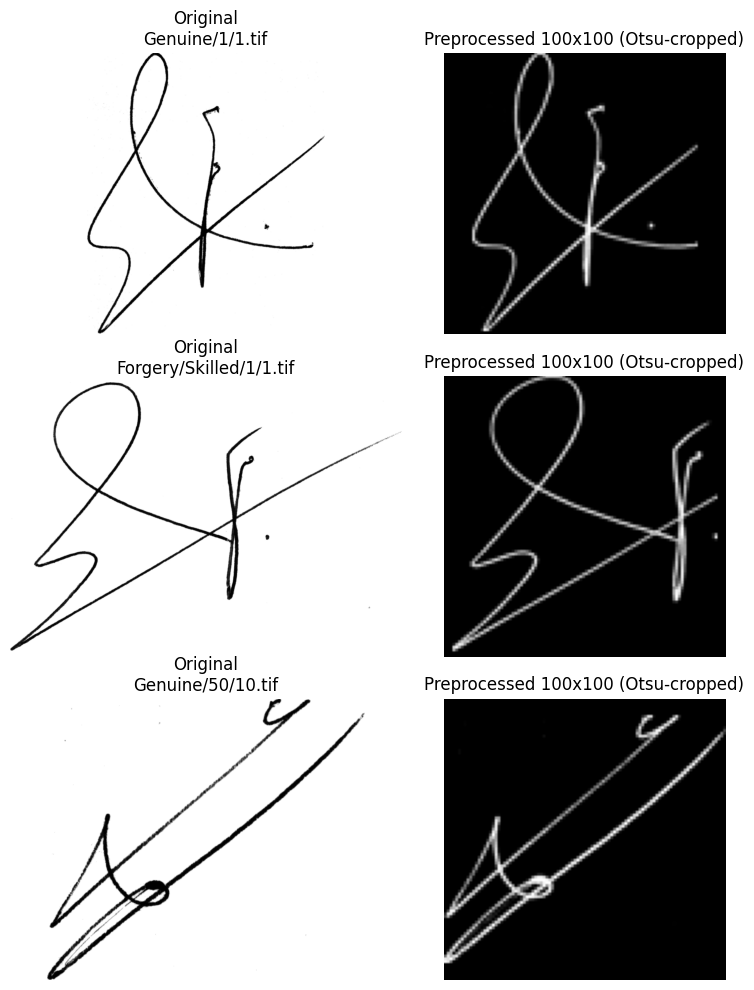

In [10]:
sample_files = [
    GENUINE_DIR / "1" / "1.tif",
    SKILLED_FORGED_DIR / "1" / "1.tif",
    GENUINE_DIR / "50" / "10.tif"
]

fig, axes = plt.subplots(len(sample_files), 2, figsize=(8, 10))

for row, image_path in enumerate(sample_files):
    original = Image.open(image_path).convert("L")
    processed = preprocess_signature(image_path)

    axes[row, 0].imshow(original, cmap="gray")
    axes[row, 0].set_title(f"Original\n{image_path.relative_to(UTSIG_DIR)}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(processed, cmap="gray")
    axes[row, 1].set_title("Preprocessed 100x100 (Otsu-cropped)")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


## RAW Pixel Features (Baseline)

In [11]:
def create_raw_features(image_paths):
    features = []
    for path in image_paths:
        img = preprocess_signature(path)
        img = img.astype(np.float32) / 255.0
        features.append(img.flatten())
    return np.array(features)

print("RAW feature extraction function created.")


RAW feature extraction function created.


In [12]:
# NOTE: final-test files are NOT featurized here, same discipline as CEDAR --
# left untouched until hyperparameters are locked on validation.
X_train_raw = create_raw_features(train_genuine_files)
X_validation_genuine_raw = create_raw_features(validation_genuine_files)
X_validation_forged_raw = create_raw_features(validation_forged_files)

print("===== RAW FEATURE SHAPES (train + validation only) =====")
print("Training genuine:", X_train_raw.shape)
print("Validation genuine:", X_validation_genuine_raw.shape)
print("Validation forged:", X_validation_forged_raw.shape)


===== RAW FEATURE SHAPES (train + validation only) =====
Training genuine: (2415, 10000)
Validation genuine: (345, 10000)
Validation forged: (345, 10000)


## HOG Features

In [13]:
def create_hog_features(image_paths):
    features = []
    for path in image_paths:
        img = preprocess_signature(path)
        img = img.astype(np.float32) / 255.0
        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True
        )
        features.append(hog_features)
    return np.array(features)

print("HOG feature extraction function created.")


HOG feature extraction function created.


In [14]:
X_train_hog = create_hog_features(train_genuine_files)
X_validation_genuine_hog = create_hog_features(validation_genuine_files)
X_validation_forged_hog = create_hog_features(validation_forged_files)

print("===== HOG FEATURE SHAPES (train + validation only) =====")
print("Training genuine:", X_train_hog.shape)
print("Validation genuine:", X_validation_genuine_hog.shape)
print("Validation forged:", X_validation_forged_hog.shape)


===== HOG FEATURE SHAPES (train + validation only) =====
Training genuine: (2415, 4356)
Validation genuine: (345, 4356)
Validation forged: (345, 4356)


## StandardScaler

Same design decision as CEDAR, restated here: one GLOBAL scaler per feature representation,
fit only on the pooled 2415 (=115x21) training-genuine signatures, not one scaler per writer
-- fitting per-writer on only 21 samples in a 10,000-d (RAW) or high-dimensional (HOG) space
would be noisier, not more precise. Final-test data is intentionally not touched here.

In [15]:
raw_scaler = StandardScaler()
hog_scaler = StandardScaler()

raw_scaler.fit(X_train_raw)
hog_scaler.fit(X_train_hog)

X_train_raw_scaled = raw_scaler.transform(X_train_raw)
X_validation_genuine_raw_scaled = raw_scaler.transform(X_validation_genuine_raw)
X_validation_forged_raw_scaled = raw_scaler.transform(X_validation_forged_raw)

X_train_hog_scaled = hog_scaler.transform(X_train_hog)
X_validation_genuine_hog_scaled = hog_scaler.transform(X_validation_genuine_hog)
X_validation_forged_hog_scaled = hog_scaler.transform(X_validation_forged_hog)

print("Scaling complete (train + validation only; final-test is scaled later).")
print("RAW train scaled shape:", X_train_raw_scaled.shape)
print("HOG train scaled shape:", X_train_hog_scaled.shape)


Scaling complete (train + validation only; final-test is scaled later).
RAW train scaled shape: (2415, 10000)
HOG train scaled shape: (2415, 4356)


## Tune OCSVM Hyperparameters

Same reference-gamma method, same fixed multiplier grid, same nu grid as CEDAR's locked
pipeline -- reused as-is rather than re-picked for UTSig, so this stays a fair
methodological comparison and not a second round of "tune until it looks good.

In [16]:
def gamma_scale_reference(X):
    """Data-driven reference gamma, matching sklearn's gamma='scale' heuristic."""
    return 1.0 / (X.shape[1] * X.var())

RAW_GAMMA_REF = gamma_scale_reference(X_train_raw_scaled)
HOG_GAMMA_REF = gamma_scale_reference(X_train_hog_scaled)

print("RAW reference gamma:", RAW_GAMMA_REF)
print("HOG reference gamma:", HOG_GAMMA_REF)

GAMMA_MULTIPLIERS = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
NU_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]

RAW_GAMMA_VALUES = [m * RAW_GAMMA_REF for m in GAMMA_MULTIPLIERS]
HOG_GAMMA_VALUES = [m * HOG_GAMMA_REF for m in GAMMA_MULTIPLIERS]

print("\nRAW gamma grid:", [f"{g:.2e}" for g in RAW_GAMMA_VALUES])
print("HOG gamma grid:", [f"{g:.2e}" for g in HOG_GAMMA_VALUES])
print("\nNu grid (shared):", NU_VALUES)


RAW reference gamma: 0.000100502526
HOG reference gamma: 0.00022956858

RAW gamma grid: ['1.01e-06', '3.02e-06', '1.01e-05', '3.02e-05', '1.01e-04', '3.02e-04', '1.01e-03', '3.02e-03', '1.01e-02']
HOG gamma grid: ['2.30e-06', '6.89e-06', '2.30e-05', '6.89e-05', '2.30e-04', '6.89e-04', '2.30e-03', '6.89e-03', '2.30e-02']

Nu grid (shared): [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]


In [17]:
def kernel_scale_check(X_train, gamma, label):
    dists_sq = pdist(X_train, metric="sqeuclidean")
    mean_sq_dist = dists_sq.mean()
    product = gamma * mean_sq_dist
    flag = "  <-- WARNING: kernel nearly flat/degenerate" if product < 0.01 else ""
    print(f"{label}: gamma={gamma:.3e}  gamma*mean_sq_dist={product:.4f}{flag}")
    return product

print("=== Sanity check: smallest and largest gamma in each grid (pooled, 2415 samples) ===")
kernel_scale_check(X_train_raw_scaled, min(RAW_GAMMA_VALUES), "RAW (smallest gamma)")
kernel_scale_check(X_train_raw_scaled, max(RAW_GAMMA_VALUES), "RAW (largest gamma)")
kernel_scale_check(X_train_hog_scaled, min(HOG_GAMMA_VALUES), "HOG (smallest gamma)")
kernel_scale_check(X_train_hog_scaled, max(HOG_GAMMA_VALUES), "HOG (largest gamma)")


=== Sanity check: smallest and largest gamma in each grid (pooled, 2415 samples) ===
RAW (smallest gamma): gamma=1.005e-06  gamma*mean_sq_dist=0.0200
RAW (largest gamma): gamma=1.005e-02  gamma*mean_sq_dist=200.0829
HOG (smallest gamma): gamma=2.296e-06  gamma*mean_sq_dist=0.0200
HOG (largest gamma): gamma=2.296e-02  gamma*mean_sq_dist=200.0830


np.float64(200.08300842694004)

### Validation tuning function

Writer range and per-writer count assertions are UTSig-specific (21 train / 3 val-genuine /
3 val-forged per writer, 115 writers) -- everything else mirrors CEDAR's `tune_ocsvm_validation`
exactly.

In [18]:
def tune_ocsvm_validation_utsig(feature_type, X_train, X_val_genuine, X_val_forged,
                                 train_files, val_genuine_files, val_forged_files,
                                 nu_values, gamma_values):
    results = []

    for nu in nu_values:
        for gamma in gamma_values:
            writer_f1, writer_far, writer_frr = [], [], []
            writer_accuracy, writer_precision, writer_recall = [], [], []

            for writer_id in range(1, 116):
                train_indices = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
                val_g_indices = [i for i, p in enumerate(val_genuine_files) if get_writer_id(p) == writer_id]
                val_f_indices = [i for i, p in enumerate(val_forged_files) if get_writer_id(p) == writer_id]

                assert len(train_indices) == 21
                assert len(val_g_indices) == 3
                assert len(val_f_indices) == 3

                X_writer_train = X_train[train_indices]
                X_writer_genuine = X_val_genuine[val_g_indices]
                X_writer_forged = X_val_forged[val_f_indices]

                X_writer_val = np.vstack([X_writer_genuine, X_writer_forged])
                y_writer_val = np.concatenate([np.ones(len(X_writer_genuine)), np.zeros(len(X_writer_forged))])

                model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
                model.fit(X_writer_train)

                y_pred = (model.predict(X_writer_val) == 1).astype(int)

                writer_accuracy.append(accuracy_score(y_writer_val, y_pred))
                writer_precision.append(precision_score(y_writer_val, y_pred, zero_division=0))
                writer_recall.append(recall_score(y_writer_val, y_pred, zero_division=0))
                writer_f1.append(f1_score(y_writer_val, y_pred, zero_division=0))

                genuine_preds = y_pred[:len(X_writer_genuine)]
                forged_preds = y_pred[len(X_writer_genuine):]
                writer_frr.append(np.mean(genuine_preds == 0))
                writer_far.append(np.mean(forged_preds == 1))

            results.append({
                "nu": nu, "gamma": gamma,
                "FAR": np.mean(writer_far), "FRR": np.mean(writer_frr),
                "Accuracy": np.mean(writer_accuracy), "Precision": np.mean(writer_precision),
                "Recall": np.mean(writer_recall), "F1": np.mean(writer_f1)
            })

    results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False).reset_index(drop=True)

    print(f"\n===== {feature_type} VALIDATION TUNING (top 15 by F1) =====\n")
    display(results_df.head(15))

    best = results_df.iloc[0]
    print("\n===== SELECTED PARAMETERS =====")
    print("Feature type:", feature_type)
    print("nu =", best["nu"], " gamma =", best["gamma"])
    print("Mean F1 =", best["F1"], " Mean FRR =", best["FRR"], " Mean FAR =", best["FAR"])

    return results_df, best

print("Tuning function defined.")


Tuning function defined.


In [19]:
# Run tuning EXACTLY ONCE per representation -- same discipline as CEDAR.
raw_tuning_results, best_raw = tune_ocsvm_validation_utsig(
    feature_type="RAW",
    X_train=X_train_raw_scaled,
    X_val_genuine=X_validation_genuine_raw_scaled,
    X_val_forged=X_validation_forged_raw_scaled,
    train_files=train_genuine_files,
    val_genuine_files=validation_genuine_files,
    val_forged_files=validation_forged_files,
    nu_values=NU_VALUES,
    gamma_values=RAW_GAMMA_VALUES
)

hog_tuning_results, best_hog = tune_ocsvm_validation_utsig(
    feature_type="HOG",
    X_train=X_train_hog_scaled,
    X_val_genuine=X_validation_genuine_hog_scaled,
    X_val_forged=X_validation_forged_hog_scaled,
    train_files=train_genuine_files,
    val_genuine_files=validation_genuine_files,
    val_forged_files=validation_forged_files,
    nu_values=NU_VALUES,
    gamma_values=HOG_GAMMA_VALUES
)

RAW_NU, RAW_GAMMA = float(best_raw["nu"]), float(best_raw["gamma"])
HOG_NU, HOG_GAMMA = float(best_hog["nu"]), float(best_hog["gamma"])

print("\n===== LOCKED FINAL HYPERPARAMETERS =====")
print("RAW: nu =", RAW_NU, " gamma =", RAW_GAMMA)
print("HOG: nu =", HOG_NU, " gamma =", HOG_GAMMA)



===== RAW VALIDATION TUNING (top 15 by F1) =====



,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,0.15,0.000001,0.440580,0.443478,0.557971,0.588986,0.556522,0.537453
1,0.15,0.000003,0.428986,0.449275,0.560870,0.588406,0.550725,0.535176
2,0.10,0.000001,0.443478,0.446377,0.555072,0.586377,0.553623,0.534969
3,0.20,0.000001,0.428986,0.452174,0.559420,0.586377,0.547826,0.533913
4,0.10,0.000003,0.434783,0.452174,0.556522,0.584928,0.547826,0.532070
5,0.05,0.000001,0.440580,0.452174,0.553623,0.583478,0.547826,0.530725
6,0.05,0.000003,0.431884,0.455072,0.556522,0.584928,0.544928,0.529462
7,0.20,0.000003,0.426087,0.466667,0.553623,0.581594,0.533333,0.522340
8,0.25,0.000001,0.423188,0.475362,0.550725,0.581594,0.524638,0.518427
9,0.05,0.000010,0.417391,0.472464,0.555072,0.580870,0.527536,0.518075



===== SELECTED PARAMETERS =====
Feature type: RAW
nu = 0.15  gamma = 1.0050251830762136e-06
Mean F1 = 0.5374534161490683  Mean FRR = 0.4434782608695652  Mean FAR = 0.4405797101449275

===== HOG VALIDATION TUNING (top 15 by F1) =====



,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,0.20,0.000002,0.252174,0.579710,0.584058,0.607971,0.420290,0.464451
1,0.15,0.000002,0.260870,0.582609,0.578261,0.599275,0.417391,0.460973
2,0.25,0.000007,0.234783,0.594203,0.585507,0.610870,0.405797,0.455673
3,0.10,0.000007,0.255072,0.588406,0.578261,0.594928,0.411594,0.454638
4,0.05,0.000007,0.246377,0.591304,0.581159,0.597101,0.408696,0.453271
5,0.20,0.000007,0.249275,0.591304,0.579710,0.592754,0.408696,0.452402
6,0.25,0.000002,0.240580,0.597101,0.581159,0.600870,0.402899,0.452070
7,0.15,0.000007,0.255072,0.591304,0.576812,0.586232,0.408696,0.450290
8,0.10,0.000002,0.263768,0.594203,0.571014,0.575362,0.405797,0.445818
9,0.05,0.000002,0.252174,0.602899,0.572464,0.584783,0.397101,0.442133



===== SELECTED PARAMETERS =====
Feature type: HOG
nu = 0.2  gamma = 2.295685817443882e-06
Mean F1 = 0.4644513457556935  Mean FRR = 0.5797101449275363  Mean FAR = 0.25217391304347825

===== LOCKED FINAL HYPERPARAMETERS =====
RAW: nu = 0.15  gamma = 1.0050251830762136e-06
HOG: nu = 0.2  gamma = 2.295685817443882e-06


## Diagnostic: Per-Writer Kernel Scale Check (run BEFORE final test)

Same diagnostic CEDAR used to catch a pooled-check-passes-but-per-writer-is-degenerate
situation. Reported for transparency; **the within-writer gamma re-anchoring idea already
tested negative on CEDAR (no improvement, or slightly worse HOG F1), so it is intentionally
not repeated here** -- only reported as a diagnostic, not acted on.

In [20]:
def kernel_scale_check_per_writer_utsig(X_train, train_files, gamma, label):
    products = []
    for writer_id in range(1, 116):
        idx = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
        X_w = X_train[idx]
        dists_sq = pdist(X_w, metric="sqeuclidean")
        products.append(gamma * dists_sq.mean())
    products = np.array(products)
    n_degenerate = int((products < 0.01).sum())
    print(f"{label}: mean={products.mean():.4f}  min={products.min():.4f}  "
          f"max={products.max():.4f}  writers_below_0.01={n_degenerate}/115")
    return products

print("===== PER-WRITER KERNEL SCALE CHECK (locked gamma) =====\n")
raw_perwriter_scale = kernel_scale_check_per_writer_utsig(X_train_raw_scaled, train_genuine_files, RAW_GAMMA, "RAW")
hog_perwriter_scale = kernel_scale_check_per_writer_utsig(X_train_hog_scaled, train_genuine_files, HOG_GAMMA, "HOG")


===== PER-WRITER KERNEL SCALE CHECK (locked gamma) =====

RAW: mean=0.0182  min=0.0028  max=0.0572  writers_below_0.01=30/115
HOG: mean=0.0150  min=0.0048  max=0.0445  writers_below_0.01=33/115


## Final Training and Final Testing

Same structure as CEDAR's `final_evaluation`, with UTSig's own per-writer counts (21 train,
3 genuine + 3 forged test) and writer range (1-115) baked into the assertions.

In [21]:
def final_evaluation_utsig(feature_type, X_train, X_test_genuine, X_test_forged,
                            train_files, test_genuine_files, test_forged_files,
                            nu, gamma):
    writer_results = []

    for writer_id in range(1, 116):
        train_indices = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
        test_g_indices = [i for i, p in enumerate(test_genuine_files) if get_writer_id(p) == writer_id]
        test_f_indices = [i for i, p in enumerate(test_forged_files) if get_writer_id(p) == writer_id]

        assert len(train_indices) == 21
        assert len(test_g_indices) == 3
        assert len(test_f_indices) == 3

        X_writer_train = X_train[train_indices]
        X_writer_genuine = X_test_genuine[test_g_indices]
        X_writer_forged = X_test_forged[test_f_indices]
        X_writer_test = np.vstack([X_writer_genuine, X_writer_forged])
        y_writer_test = np.concatenate([np.ones(len(X_writer_genuine)), np.zeros(len(X_writer_forged))])

        model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
        model.fit(X_writer_train)

        y_pred = (model.predict(X_writer_test) == 1).astype(int)

        accuracy = accuracy_score(y_writer_test, y_pred)
        precision = precision_score(y_writer_test, y_pred, zero_division=0)
        recall = recall_score(y_writer_test, y_pred, zero_division=0)
        f1 = f1_score(y_writer_test, y_pred, zero_division=0)

        genuine_predictions = y_pred[:len(X_writer_genuine)]
        forged_predictions = y_pred[len(X_writer_genuine):]
        frr = np.mean(genuine_predictions == 0)
        far = np.mean(forged_predictions == 1)

        writer_results.append({
            "Writer": writer_id, "FAR": far, "FRR": frr,
            "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1": f1
        })

    writer_results_df = pd.DataFrame(writer_results)

    overall_results = {
        "Feature": feature_type, "nu": nu, "gamma": gamma,
        "FAR": writer_results_df["FAR"].mean(),
        "FRR": writer_results_df["FRR"].mean(),
        "Accuracy": writer_results_df["Accuracy"].mean(),
        "Precision": writer_results_df["Precision"].mean(),
        "Recall": writer_results_df["Recall"].mean(),
        "F1": writer_results_df["F1"].mean()
    }

    return writer_results_df, overall_results

print("Final evaluation function defined.")


Final evaluation function defined.


In [22]:
# Final-test features + scaling, loaded only now that hyperparameters are locked.
X_final_test_genuine_raw = create_raw_features(final_test_genuine_files)
X_final_test_forged_raw = create_raw_features(final_test_forged_files)
X_final_test_genuine_hog = create_hog_features(final_test_genuine_files)
X_final_test_forged_hog = create_hog_features(final_test_forged_files)

X_final_test_genuine_raw_scaled = raw_scaler.transform(X_final_test_genuine_raw)
X_final_test_forged_raw_scaled = raw_scaler.transform(X_final_test_forged_raw)
X_final_test_genuine_hog_scaled = hog_scaler.transform(X_final_test_genuine_hog)
X_final_test_forged_hog_scaled = hog_scaler.transform(X_final_test_forged_hog)

print("Final-test features created and scaled.")
print("RAW genuine/forged:", X_final_test_genuine_raw_scaled.shape, X_final_test_forged_raw_scaled.shape)
print("HOG genuine/forged:", X_final_test_genuine_hog_scaled.shape, X_final_test_forged_hog_scaled.shape)


Final-test features created and scaled.
RAW genuine/forged: (345, 10000) (345, 10000)
HOG genuine/forged: (345, 4356) (345, 4356)


In [23]:
raw_writer_results, raw_final_results = final_evaluation_utsig(
    feature_type="RAW",
    X_train=X_train_raw_scaled,
    X_test_genuine=X_final_test_genuine_raw_scaled,
    X_test_forged=X_final_test_forged_raw_scaled,
    train_files=train_genuine_files,
    test_genuine_files=final_test_genuine_files,
    test_forged_files=final_test_forged_files,
    nu=RAW_NU, gamma=RAW_GAMMA
)
raw_writer_df = pd.DataFrame(raw_writer_results)

hog_writer_results, hog_final_results = final_evaluation_utsig(
    feature_type="HOG",
    X_train=X_train_hog_scaled,
    X_test_genuine=X_final_test_genuine_hog_scaled,
    X_test_forged=X_final_test_forged_hog_scaled,
    train_files=train_genuine_files,
    test_genuine_files=final_test_genuine_files,
    test_forged_files=final_test_forged_files,
    nu=HOG_NU, gamma=HOG_GAMMA
)
hog_writer_df = pd.DataFrame(hog_writer_results)

print("RAW final evaluation completed.")
print("HOG final evaluation completed.")


RAW final evaluation completed.
HOG final evaluation completed.


### Overfitting diagnostic: Train -> Validation -> Final-Test FRR

In [24]:
def training_self_prediction_utsig(feature_type, X_train, train_files, nu, gamma):
    writer_results = []
    for writer_id in range(1, 116):
        train_indices = [i for i, p in enumerate(train_files) if get_writer_id(p) == writer_id]
        assert len(train_indices) == 21
        X_writer_train = X_train[train_indices]

        model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
        model.fit(X_writer_train)

        y_pred = (model.predict(X_writer_train) == 1).astype(int)
        writer_results.append({
            "Writer": writer_id,
            "Train_FRR": np.mean(y_pred == 0),
            "Train_Acceptance_Rate": np.mean(y_pred == 1)
        })

    writer_results_df = pd.DataFrame(writer_results)
    overall = {
        "Feature": feature_type, "nu": nu, "gamma": gamma,
        "Mean_Train_FRR": writer_results_df["Train_FRR"].mean(),
        "Mean_Train_Acceptance_Rate": writer_results_df["Train_Acceptance_Rate"].mean()
    }
    return writer_results_df, overall

raw_train_diag_df, raw_train_diag_summary = training_self_prediction_utsig(
    "RAW", X_train_raw_scaled, train_genuine_files, RAW_NU, RAW_GAMMA
)
hog_train_diag_df, hog_train_diag_summary = training_self_prediction_utsig(
    "HOG", X_train_hog_scaled, train_genuine_files, HOG_NU, HOG_GAMMA
)

print("===== TRAINING-SET SELF-PREDICTION SUMMARY =====\n")
display(pd.DataFrame([raw_train_diag_summary, hog_train_diag_summary]))

frr_progression = pd.DataFrame([
    {
        "Feature": "RAW",
        "Train_FRR": raw_train_diag_summary["Mean_Train_FRR"],
        "Validation_FRR": best_raw["FRR"],
        "Final_Test_FRR": raw_final_results["FRR"]
    },
    {
        "Feature": "HOG",
        "Train_FRR": hog_train_diag_summary["Mean_Train_FRR"],
        "Validation_FRR": best_hog["FRR"],
        "Final_Test_FRR": hog_final_results["FRR"]
    }
])

print("\n===== TRAIN -> VALIDATION -> FINAL-TEST FRR PROGRESSION =====\n")
display(frr_progression)


===== TRAINING-SET SELF-PREDICTION SUMMARY =====



,Feature,nu,gamma,Mean_Train_FRR,Mean_Train_Acceptance_Rate
0,RAW,0.15,0.000001,0.241822,0.758178
1,HOG,0.20,0.000002,0.300207,0.699793



===== TRAIN -> VALIDATION -> FINAL-TEST FRR PROGRESSION =====



,Feature,Train_FRR,Validation_FRR,Final_Test_FRR
0,RAW,0.241822,0.443478,0.385507
1,HOG,0.300207,0.579710,0.559420


## RAW vs HOG Final-Test Comparison

In [25]:
final_comparison = pd.DataFrame([raw_final_results, hog_final_results])
print("\n===== FINAL RAW vs HOG RESULTS (UTSig, Skilled forgeries) =====\n")
display(final_comparison)



===== FINAL RAW vs HOG RESULTS (UTSig, Skilled forgeries) =====



,Feature,nu,gamma,FAR,FRR,Accuracy,Precision,Recall,F1
0,RAW,0.15,0.000001,0.489855,0.385507,0.562319,0.591014,0.614493,0.564658
1,HOG,0.20,0.000002,0.260870,0.559420,0.589855,0.605217,0.440580,0.475652


In [26]:
comparison_metrics = ["FAR", "FRR", "Accuracy", "Precision", "Recall", "F1"]
winner_rows = []

for metric in comparison_metrics:
    raw_value = raw_final_results[metric]
    hog_value = hog_final_results[metric]

    if metric in ["FAR", "FRR"]:
        winner = "RAW" if raw_value < hog_value else ("HOG" if hog_value < raw_value else "Tie")
    else:
        winner = "RAW" if raw_value > hog_value else ("HOG" if hog_value > raw_value else "Tie")

    winner_rows.append({"Metric": metric, "RAW": raw_value, "HOG": hog_value, "Better Model": winner})

metric_winner_df = pd.DataFrame(winner_rows)
display(metric_winner_df)


,Metric,RAW,HOG,Better Model
0,FAR,0.489855,0.260870,HOG
1,FRR,0.385507,0.559420,RAW
2,Accuracy,0.562319,0.589855,HOG
3,Precision,0.591014,0.605217,HOG
4,Recall,0.614493,0.440580,RAW
5,F1,0.564658,0.475652,RAW


## Trivial Baselines and Balanced Accuracy

**Read this before comparing to CEDAR's baseline numbers.** CEDAR's final-test set is 165
genuine / 660 forged (80% forged), so its Reject-All baseline scores 80% accuracy "for
free." UTSig's final-test set is 345 genuine / 345 forged (50/50) because only 6
skilled-forged signatures exist per writer -- so here Reject-All and Accept-All both score
only ~50% accuracy. A UTSig F1/accuracy that looks numerically similar to a CEDAR number is
therefore NOT an apples-to-apples improvement or regression; what matters is each model's
margin over its OWN dataset's trivial baselines, shown side by side below.

In [27]:
n_test_genuine = len(final_test_genuine_files)
n_test_forged = len(final_test_forged_files)
n_test_total = n_test_genuine + n_test_forged

def balanced_accuracy(far, frr):
    return ((1 - frr) + (1 - far)) / 2

reject_all = {"Feature": "Reject-All Baseline", "FAR": 0.0, "FRR": 1.0,
              "Accuracy": n_test_forged / n_test_total,
              "Precision": float("nan"), "Recall": 0.0, "F1": 0.0}
p_accept = n_test_genuine / n_test_total
accept_all = {"Feature": "Accept-All Baseline", "FAR": 1.0, "FRR": 0.0,
              "Accuracy": p_accept, "Precision": p_accept, "Recall": 1.0,
              "F1": 2 * p_accept / (1 + p_accept)}

baseline_comparison = pd.DataFrame([
    {**raw_final_results, "Balanced_Accuracy": balanced_accuracy(raw_final_results["FAR"], raw_final_results["FRR"])},
    {**hog_final_results, "Balanced_Accuracy": balanced_accuracy(hog_final_results["FAR"], hog_final_results["FRR"])},
    {**reject_all, "Balanced_Accuracy": balanced_accuracy(reject_all["FAR"], reject_all["FRR"])},
    {**accept_all, "Balanced_Accuracy": balanced_accuracy(accept_all["FAR"], accept_all["FRR"])},
])

print(f"===== FINAL RESULTS vs TRIVIAL BASELINES (n_genuine={n_test_genuine}, n_forged={n_test_forged}) =====\n")
display(baseline_comparison[["Feature", "FAR", "FRR", "Accuracy", "Balanced_Accuracy", "Precision", "Recall", "F1"]])


===== FINAL RESULTS vs TRIVIAL BASELINES (n_genuine=345, n_forged=345) =====



,Feature,FAR,FRR,Accuracy,Balanced_Accuracy,Precision,Recall,F1
0,RAW,0.489855,0.385507,0.562319,0.562319,0.591014,0.614493,0.564658
1,HOG,0.260870,0.559420,0.589855,0.589855,0.605217,0.440580,0.475652
2,Reject-All Baseline,0.000000,1.000000,0.500000,0.500000,NaN,0.000000,0.000000
3,Accept-All Baseline,1.000000,0.000000,0.500000,0.500000,0.500000,1.000000,0.666667


## Writer-Level Analysis

In [28]:
writer_comparison = pd.DataFrame({
    "Writer": raw_writer_df["Writer"],
    "RAW_FRR": raw_writer_df["FRR"],
    "HOG_FRR": hog_writer_df["FRR"],
    "RAW_F1": raw_writer_df["F1"],
    "HOG_F1": hog_writer_df["F1"]
})

writer_comparison["FRR Difference (HOG - RAW)"] = writer_comparison["HOG_FRR"] - writer_comparison["RAW_FRR"]
writer_comparison["F1 Difference (HOG - RAW)"] = writer_comparison["HOG_F1"] - writer_comparison["RAW_F1"]

display(writer_comparison)


,Writer,RAW_FRR,HOG_FRR,RAW_F1,HOG_F1,FRR Difference (HOG - RAW),F1 Difference (HOG - RAW)
0,1,0.333333,0.666667,0.800000,0.500000,0.333333,-0.300000
1,2,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
2,3,0.333333,0.000000,0.666667,1.000000,-0.333333,0.333333
3,4,0.666667,0.666667,0.500000,0.500000,0.000000,0.000000
4,5,0.000000,0.333333,0.666667,0.666667,0.333333,0.000000
...,...,...,...,...,...,...,...
110,111,0.000000,1.000000,0.857143,0.000000,1.000000,-0.857143
111,112,0.000000,1.000000,1.000000,0.000000,1.000000,-1.000000
112,113,1.000000,0.666667,0.000000,0.500000,-0.333333,0.500000
113,114,0.666667,0.333333,0.500000,0.800000,-0.333333,0.300000


In [29]:
writer_comparison["F1 Winner"] = "Tie"
writer_comparison.loc[writer_comparison["RAW_F1"] > writer_comparison["HOG_F1"], "F1 Winner"] = "RAW"
writer_comparison.loc[writer_comparison["HOG_F1"] > writer_comparison["RAW_F1"], "F1 Winner"] = "HOG"

f1_winner_counts = (
    writer_comparison["F1 Winner"]
    .value_counts()
    .reindex(["RAW", "HOG", "Tie"], fill_value=0)
    .reset_index()
)
f1_winner_counts.columns = ["Model", "Number of Writers"]
display(f1_winner_counts)


,Model,Number of Writers
0,RAW,57
1,HOG,32
2,Tie,26


## Notes for the write-up

- This is a bonus/stretch cross-dataset result, not a replacement for the CEDAR pipeline,
  which stays the primary thesis result.
- UTSig gives 21 genuine training references per writer -- more than even CEDAR's 18-train
  supplementary experiment (which used all 24 CEDAR provides) -- so this is a genuine
  extension of the "does more per-writer reference data help" question past what CEDAR alone
  could test.
- The final-test class balance differs fundamentally from CEDAR (50/50 here vs. CEDAR's
  80/20 forged-heavy split) because UTSig only provides 6 skilled forgeries per writer.
  Always report each dataset's own trivial baselines alongside its results -- do not compare
  raw accuracy/F1 numbers across datasets without that context.
- `Forgery/Simple` (36/writer) and `Forgery/Opposite Hand` (3/writer) were deliberately not
  used here. They remain available as optional future-work robustness checks (e.g., "does
  the model trained against Skilled forgeries also reject casual/Simple forgeries, and does
  it wrongly reject the genuine signer's own opposite-hand attempts?") but were out of scope
  for the core RAW-vs-HOG comparison this notebook runs.
- The within-writer gamma re-anchoring idea (tested on CEDAR, found not to help) was not
  re-tested here for the same reason it wasn't adopted there: it already failed to improve
  validation F1 once, and re-running it on a second dataset without a new reason to expect a
  different outcome would just be another form of tuning-until-satisfied.